# Model_Comparison
**Project:** Hotel Booking Demand - Supervised Learning Assignment  
**Purpose:** Load the four saved model files, evaluate them on the same test split, compare them across metrics, and identify the best-performing model.

## 1. Imports

In [2]:
# ============================================================
# Cell 1: Import comparison libraries and helper functions
# ============================================================
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown

from hotel_booking_common import (
    RANDOM_STATE,
    get_project_root,
    ensure_dir,
    load_dataset,
    prepare_hotel_booking_dataframe,
    build_train_test_split,
    compare_models_on_test_set,
)

## 2. Project configuration

In [3]:
# ============================================================
# Cell 2: Set project paths for input data and comparison outputs
# ============================================================
PROJECT_ROOT = get_project_root()
DATASET_DIR = PROJECT_ROOT / "dataset"
OUTPUT_DIR = ensure_dir(PROJECT_ROOT / "outputs" / "comparison")

MODEL_PATHS = {
    "Logistic Regression": PROJECT_ROOT / "outputs" / "logistic_regression" / "best_model.joblib",
    "Decision Tree": PROJECT_ROOT / "outputs" / "decision_tree" / "best_model.joblib",
    "Random Forest": PROJECT_ROOT / "outputs" / "random_forest" / "best_model.joblib",
    "Gradient Boosting": PROJECT_ROOT / "outputs" / "gradient_boosting" / "best_model.joblib",
}

for model_name, model_path in MODEL_PATHS.items():
    print(model_name, "->", model_path)

Logistic Regression -> /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/logistic_regression/best_model.joblib
Decision Tree -> /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/decision_tree/best_model.joblib
Random Forest -> /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/random_forest/best_model.joblib
Gradient Boosting -> /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/gradient_boosting/best_model.joblib


## 3. Load and preprocess dataset

In [4]:
# ============================================================
# Cell 3: Recreate the same cleaned dataset and hold-out split
# ============================================================
df_raw, dataset_path = load_dataset(DATASET_DIR)
df_model, preprocessing_notes = prepare_hotel_booking_dataframe(df_raw, target_col="is_canceled")

X_train, X_test, y_train, y_test = build_train_test_split(
    df_model,
    target_col="is_canceled",
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Comparison test rows: {X_test.shape[0]}")

Comparison test rows: 17446


## 4. Compare the saved models

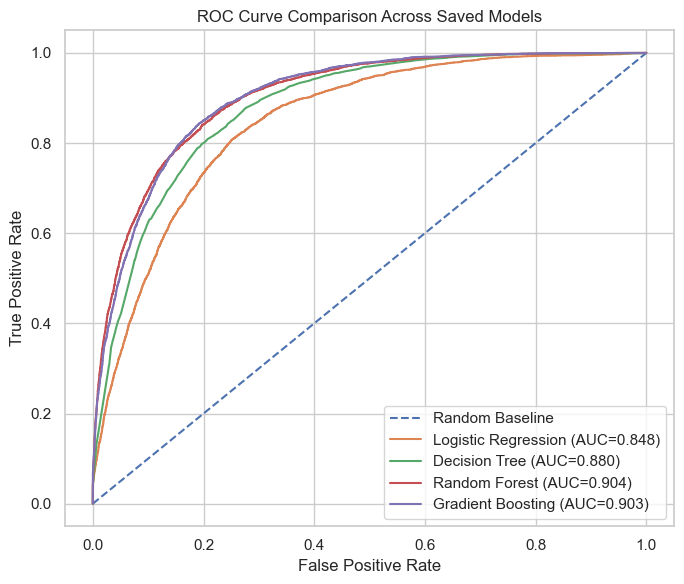

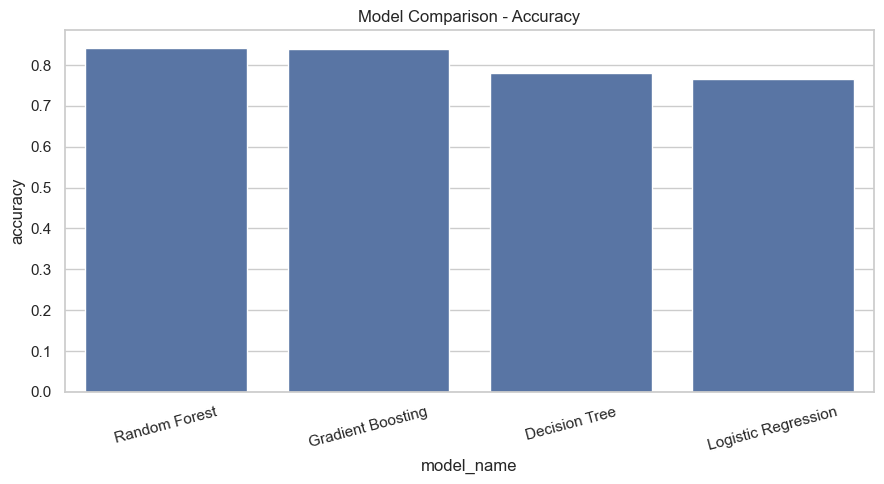

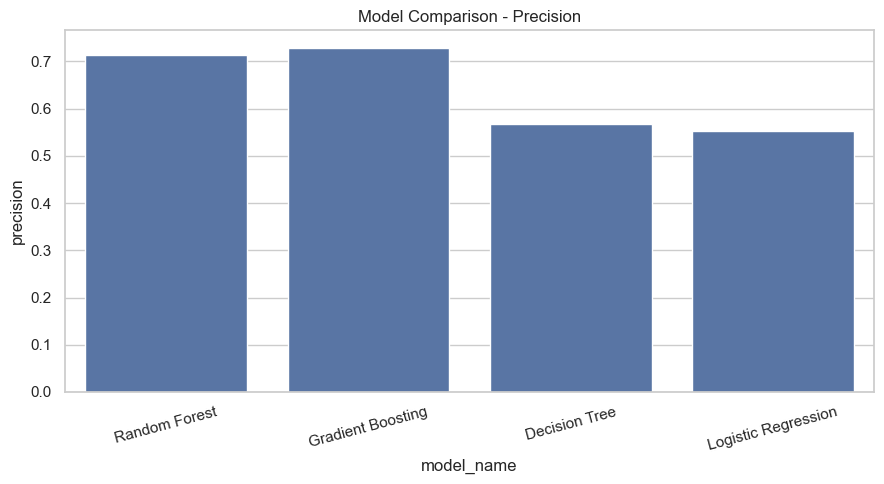

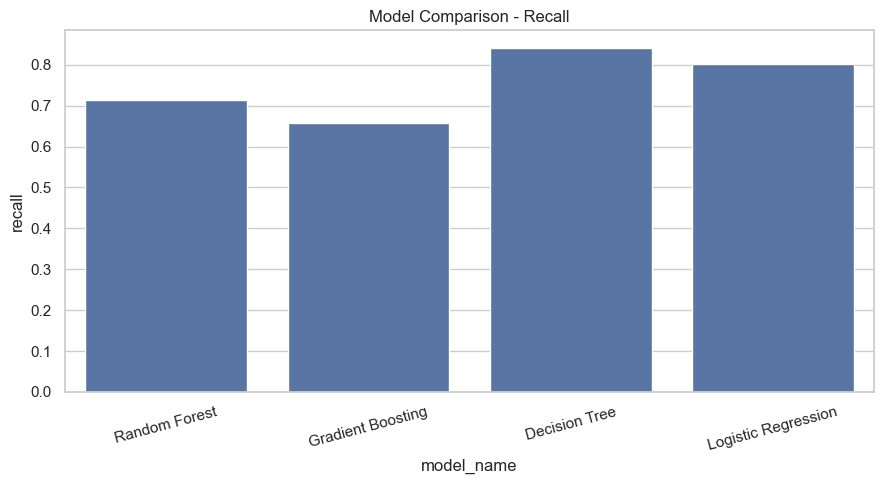

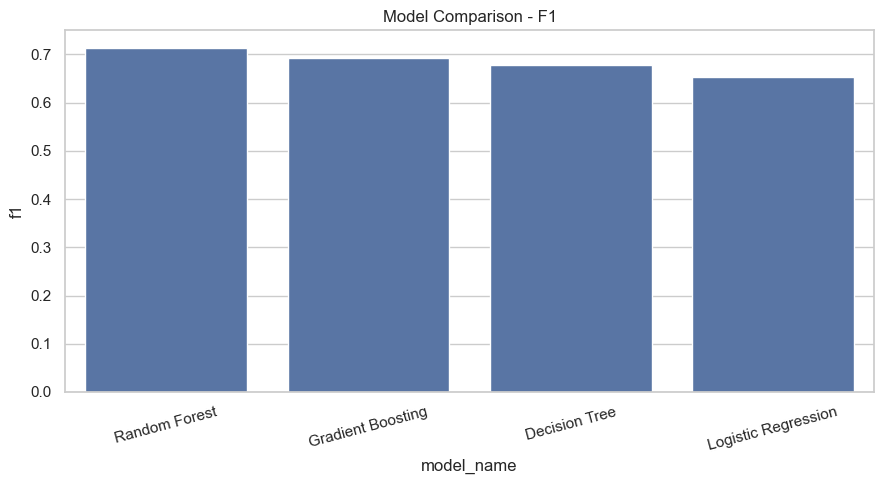

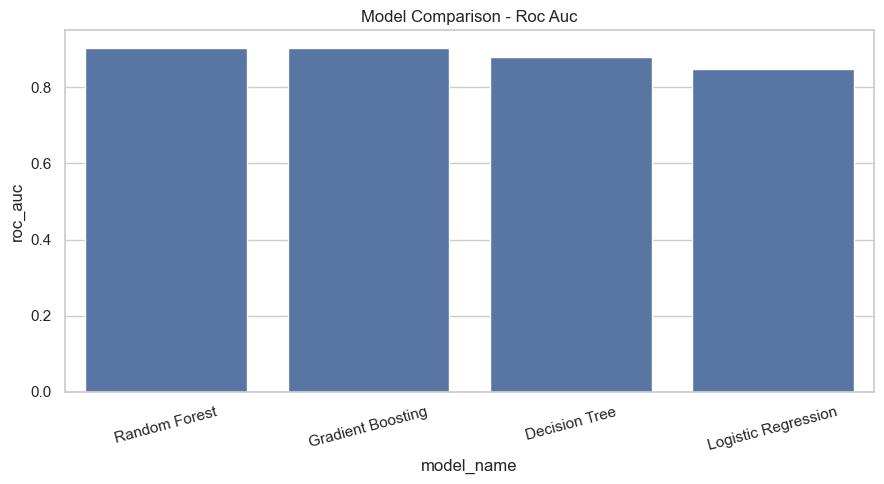

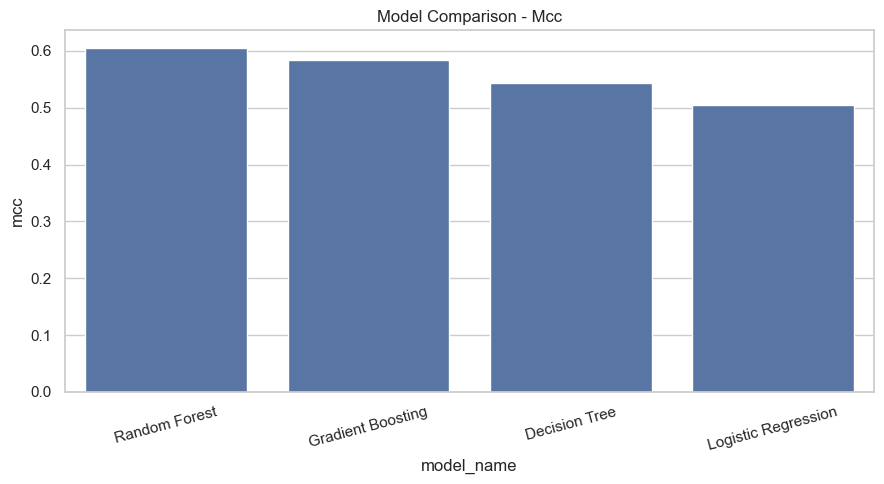

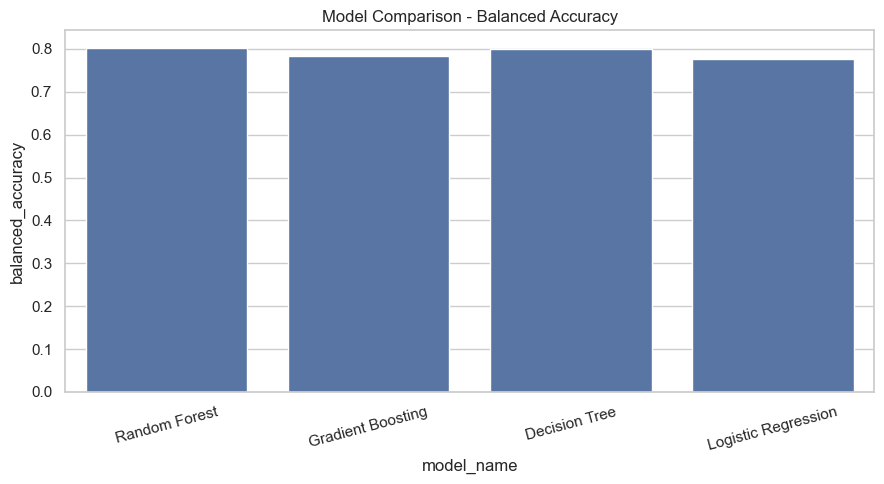

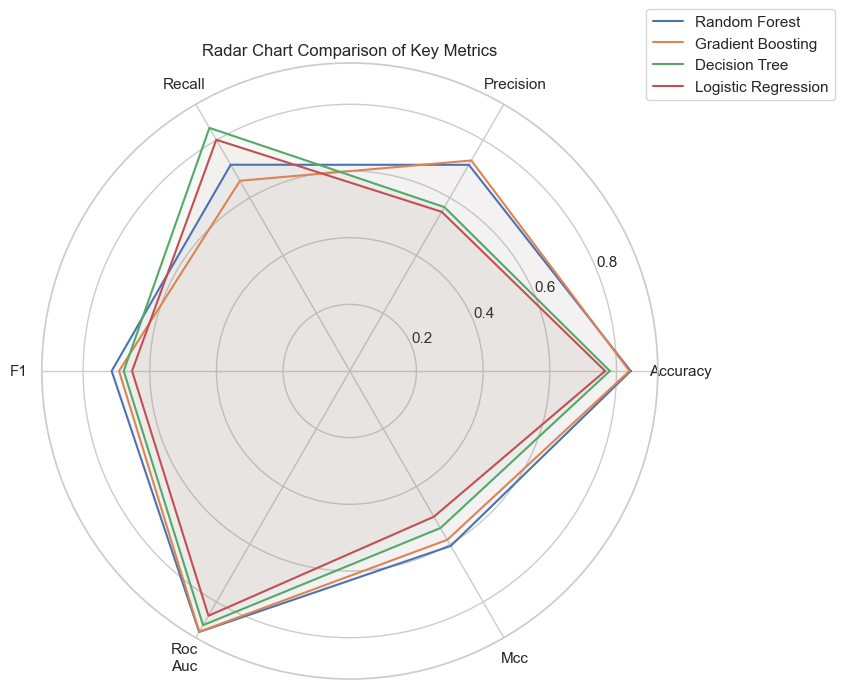

,model_name,accuracy,balanced_accuracy,precision,recall,specificity,f1,f2,roc_auc,average_precision_pr_auc,mcc,cohen_kappa,brier_score,log_loss
0,Random Forest,0.842715,0.802952,0.714197,0.714494,0.891411,0.714345,0.714434,0.903950,0.787467,0.605827,0.605827,0.110600,0.354010
1,Gradient Boosting,0.838760,0.782981,0.729200,0.658892,0.907071,0.692266,0.671848,0.903149,0.779730,0.584783,0.583407,0.110495,0.344502
2,Decision Tree,0.780007,0.799278,0.567659,0.842149,0.756406,0.678182,0.767887,0.880451,0.715514,0.543893,0.520505,0.145832,0.444065
3,Logistic Regression,0.765906,0.776763,0.551477,0.800916,0.752610,0.653193,0.734474,0.847889,0.664884,0.504703,0.485436,0.162052,0.490945


In [5]:
# ============================================================
# Cell 4: Load the saved pipelines and compare them consistently
# ============================================================
missing_models = [name for name, path in MODEL_PATHS.items() if not path.exists()]
if missing_models:
    raise FileNotFoundError(
        "Run all four algorithm notebooks first. Missing model files for: " + ", ".join(missing_models)
    )

comparison_df = compare_models_on_test_set(
    model_paths=MODEL_PATHS,
    X_test=X_test,
    y_test=y_test,
    output_dir=OUTPUT_DIR,
)

display(comparison_df)

## 5. Identify the best model

In [6]:
# ============================================================
# Cell 5: Extract and display the best overall model from the comparison
# ============================================================
best_model_row = comparison_df.iloc[0]
display(Markdown("### Best model based on ROC-AUC, F1, and MCC ranking"))
display(best_model_row.to_frame("value"))

### Best model based on ROC-AUC, F1, and MCC ranking

,value
model_name,Random Forest
accuracy,0.842715
balanced_accuracy,0.802952
precision,0.714197
recall,0.714494
specificity,0.891411
f1,0.714345
f2,0.714434
roc_auc,0.90395
average_precision_pr_auc,0.787467


## 6. Save a short comparison report

In [7]:
# ============================================================
# Cell 6: Create a short markdown report for the final write-up
# ============================================================
best_model_name = comparison_df.iloc[0]["model_name"]
report_lines = [
    "# Model Comparison Report",
    "",
    f"- Dataset file: {dataset_path.name}",
    f"- Test set size: {X_test.shape[0]}",
    f"- Best overall model: {best_model_name}",
    "",
    "## Ranking table",
    comparison_df.to_markdown(index=False),
    "",
    "## Discussion prompts",
    "- Compare performance trade-offs between interpretability and accuracy.",
    "- Discuss whether the best ROC-AUC model is also the best MCC or recall model.",
    "- Use the saved plots in outputs/comparison to support the report discussion."
]
report_path = OUTPUT_DIR / "model_comparison_report.md"
report_path.write_text("\n".join(report_lines), encoding="utf-8")
print(f"Saved comparison report to: {report_path}")

Saved comparison report to: /Users/sraveendran/Documents/GitHub/ML-Assignment/outputs/comparison/model_comparison_report.md
